# **Random Forest for Food Delivery Times Prediction**

**Projek UAS Pengantar Data Sains Semester 123**

**Nisrina Alissy (1314623008)**

**Statistika 2023A**



Deskripsi:

Menganalisis penerapan model machine learning dalam memprediksi waktu pengiriman secara akurat serta mengidentifikasi faktor-faktor yang paling berpengaruh terhadap durasi pengiriman.

### Food Delivery Times Dataset
source: https://www.kaggle.com/datasets/denkuznetz/food-delivery-time-prediction


Key Features

Order_ID: Unique identifier for each order.

Distance_km: The delivery distance in kilometers.

Weather: Weather conditions during the delivery, including Clear, Rainy, Snowy, Foggy, and Windy.

Traffic_Level: Traffic conditions categorized as Low, Medium, or High.

Time_of_Day: The time when the delivery took place, categorized as Morning, Afternoon, Evening, or Night.

Vehicle_Type: Type of vehicle used for delivery, including Bike, Scooter, and Car.

Preparation_Time_min: The time required to prepare the order, measured in minutes.

Courier_Experience_yrs: Experience of the courier in years.

Delivery_Time_min: The total delivery time in minutes (target variable).


Input data

In [ ]:
#Import library yang digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#input data
link = "https://raw.githubusercontent.com/alissysays/SMT5_NA/refs/heads/main/Project%20UAS%20PDS/Food_Delivery_Times.csv"
df = pd.read_csv(link)
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
#ringkasan statistik
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


# EDA

In [ ]:
# missing value check
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
# Handle missing value
# Fill categorical columns with mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical column with median
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

print("Jumlah Missing Value SETELAH Imputasi:")
print(df.isnull().sum())

Jumlah Missing Value SETELAH Imputasi:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [ ]:
# duplicate data check
print(f'Number of duplicates in this dataset: {df.duplicated().sum()}')
df = df.drop_duplicates()

Number of duplicates in this dataset: 0


In [ ]:
# checking unique values
df.nunique()

,0
Order_ID,1000
Distance_km,785
Weather,5
Traffic_Level,3
Time_of_Day,4
Vehicle_Type,3
Preparation_Time_min,25
Courier_Experience_yrs,10
Delivery_Time_min,108


EDA Graphs

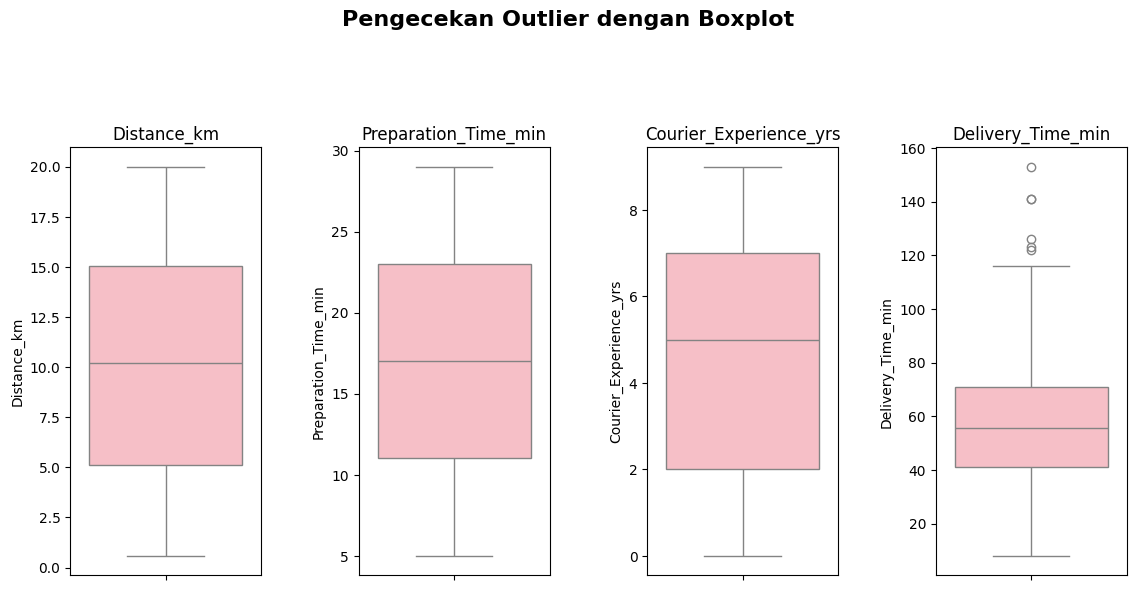

In [ ]:
#cek outlier
# Boxplot untuk mengecek outlier
# Select numerical columns
num_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

# Create boxplots
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='lightpink')
    plt.title(col)
    plt.tight_layout()
plt.suptitle("Pengecekan Outlier dengan Boxplot", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.show()

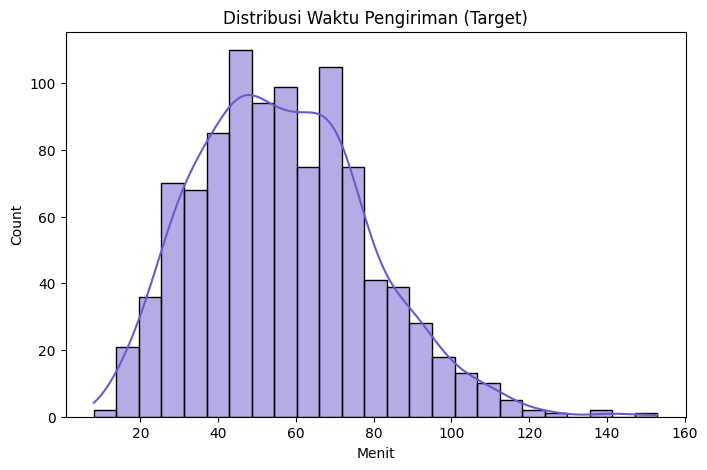

In [ ]:
# Histogram: Distribusi Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df['Delivery_Time_min'], kde=True, color='slateblue')
plt.title('Distribusi Waktu Pengiriman (Target)')
plt.xlabel('Menit')
plt.show()

/tmp/ipython-input-3484910305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='Delivery_Time_min', data=df, estimator='mean', palette='mako')


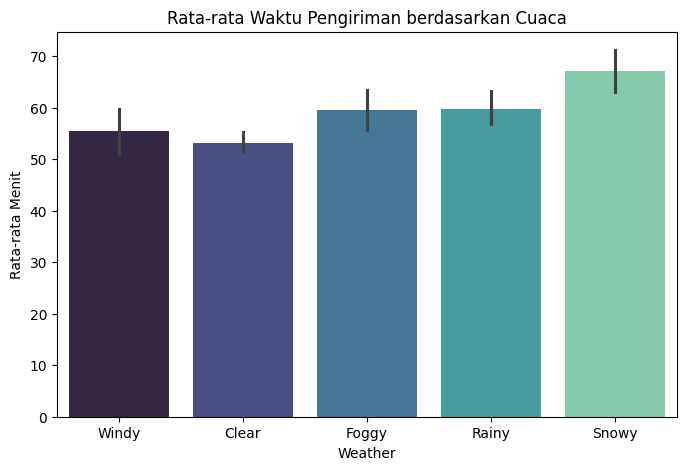

In [ ]:
#Bar Chart: Pengaruh Cuaca terhadap Waktu (Kategori vs Numerik)
plt.figure(figsize=(8, 5))
sns.barplot(x='Weather', y='Delivery_Time_min', data=df, estimator='mean', palette='mako')
plt.title('Rata-rata Waktu Pengiriman berdasarkan Cuaca')
plt.ylabel('Rata-rata Menit')
plt.show()

/tmp/ipython-input-2782891154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Traffic_Level', y='Delivery_Time_min', data=df, estimator='mean', palette='magma')


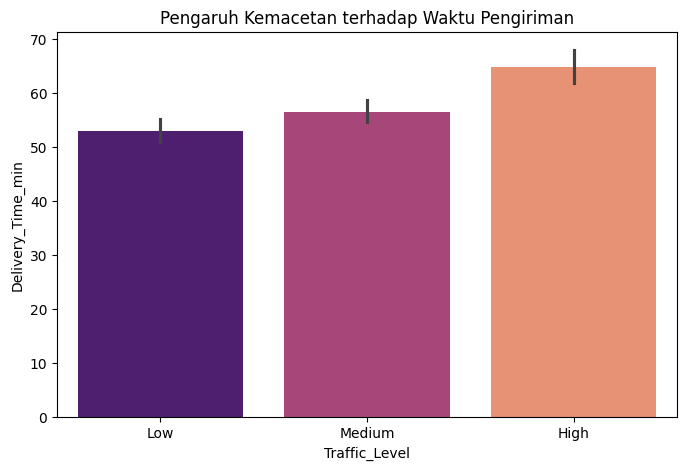

In [ ]:
#Bar Chart: Pengaruh Macet (Traffic) terhadap Waktu
plt.figure(figsize=(8, 5))
sns.barplot(x='Traffic_Level', y='Delivery_Time_min', data=df, estimator='mean', palette='magma')
plt.title('Pengaruh Kemacetan terhadap Waktu Pengiriman')
plt.show()

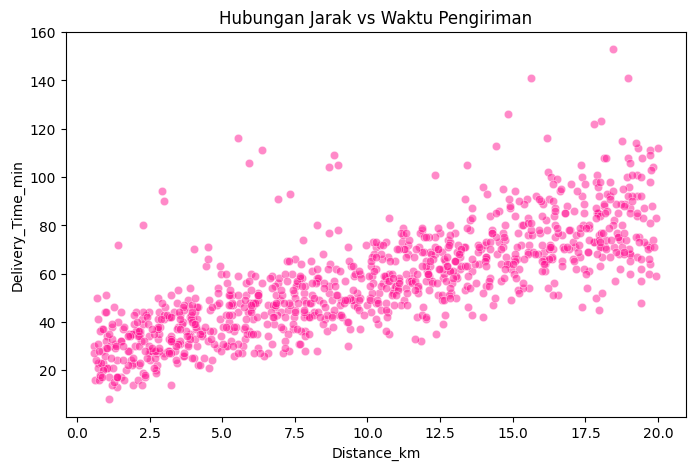

In [ ]:
#Scatter Plot: Jarak vs Waktu (Numerik vs Numerik)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_min', data=df, alpha=0.5, color='deeppink')
plt.title('Hubungan Jarak vs Waktu Pengiriman')
plt.show()

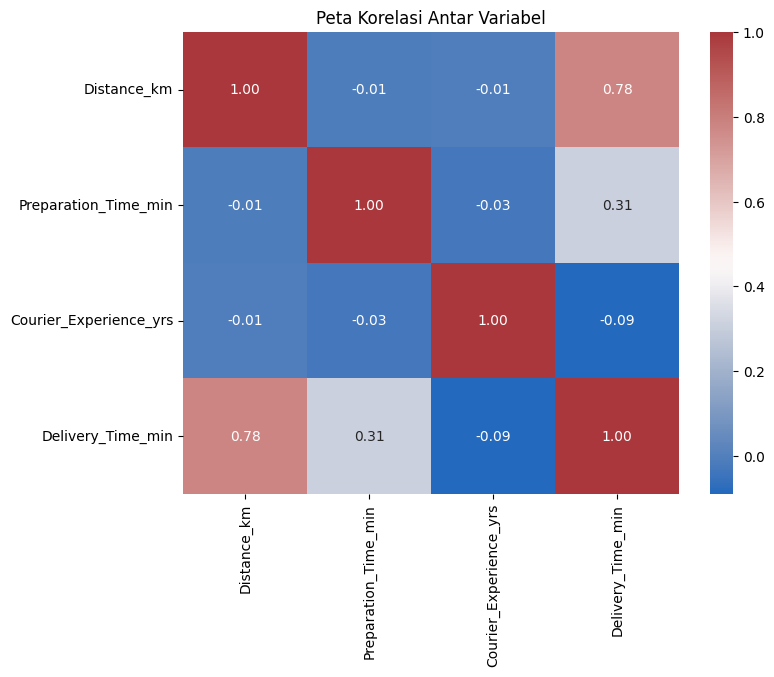

In [ ]:
#Heatmap Korelasi
plt.figure(figsize=(8, 6))

kolom_angka = df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']]
correlation = kolom_angka.corr()
sns.heatmap(correlation, annot=True, cmap='vlag', fmt=".2f")
plt.title('Peta Korelasi Antar Variabel')
plt.show()

In [ ]:
# Cek sebaran data kategori
cols_cat = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cols_cat:
    print(df[col].value_counts())
    print("-" * 20)

Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64
--------------------
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64
--------------------
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64
--------------------
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64
--------------------


In [ ]:
# Hapus kolom yang tidak berguna untuk prediksi
df.drop('Order_ID', axis=1, inplace=True)

# Preprocessing data

In [ ]:
# Encoding

# 1. Ordinal Encoding untuk Traffic (Karena punya urutan)
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}

# Ubah kolom Traffic jadi angka
df['Traffic_Level'] = df['Traffic_Level'].map(traffic_map)

# 2. One-Hot Encoding untuk sisanya (Yang tidak punya urutan)
cols_nominal = ['Weather', 'Time_of_Day', 'Vehicle_Type']
df_clean = pd.get_dummies(df, columns=cols_nominal, drop_first=True)

# Cek hasil
print(df_clean.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Traffic_Level           1000 non-null   int64  
 2   Preparation_Time_min    1000 non-null   int64  
 3   Courier_Experience_yrs  1000 non-null   float64
 4   Delivery_Time_min       1000 non-null   int64  
 5   Weather_Foggy           1000 non-null   bool   
 6   Weather_Rainy           1000 non-null   bool   
 7   Weather_Snowy           1000 non-null   bool   
 8   Weather_Windy           1000 non-null   bool   
 9   Time_of_Day_Evening     1000 non-null   bool   
 10  Time_of_Day_Morning     1000 non-null   bool   
 11  Time_of_Day_Night       1000 non-null   bool   
 12  Vehicle_Type_Car        1000 non-null   bool   
 13  Vehicle_Type_Scooter    1000 non-null   bool   
dtypes: bool(9), float64(2), int64(3)
memory u

In [ ]:
# ENCODING (One-Hot Encoding)
#df_clean = pd.get_dummies(df, columns=cols_cat, drop_first=True)

# Cek hasil akhirnya
#print("Info Data Siap Training:")
#print(df_clean.info())

In [ ]:
print(df_clean[['Traffic_Level']].head())

   Traffic_Level
0              1
1              2
2              1
3              2
4              1


In [ ]:
df_clean.head()

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1,12,1.0,43,False,False,False,True,False,False,False,False,True
1,16.42,2,20,2.0,84,False,False,False,False,True,False,False,False,False
2,9.52,1,28,1.0,59,True,False,False,False,False,False,True,False,True
3,7.44,2,5,1.0,37,False,True,False,False,False,False,False,False,True
4,19.03,1,16,5.0,68,False,False,False,False,False,True,False,False,False


In [ ]:
#split data into train and split
from sklearn.model_selection import train_test_split
X = df_clean.drop('Delivery_Time_min', axis=1)
y = df_clean['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("\n Hasil Pembagian Data (80:20):")
print(f"X_train (Data Latih Fitur): {X_train.shape}")
print(f"X_test (Data Uji Fitur): {X_test.shape}")
print(f"y_train (Data Latih Target): {y_train.shape}")
print(f"y_test (Data Uji Target): {y_test.shape}")


 Hasil Pembagian Data (80:20):
X_train (Data Latih Fitur): (800, 13)
X_test (Data Uji Fitur): (200, 13)
y_train (Data Latih Target): (800,)
y_test (Data Uji Target): (200,)


# **Random Forest prediction**

### baseline (decision tree)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Decision Tree---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluasi DT
y_pred_dt = dt_model.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
print("-- evaluasi decision tree--")
print(f"MAE: {mae_dt:.2f} menit")
print(f"RMSE: {rmse_dt:.2f}")
print(f"Akurasi (R2 Score): {r2_dt:.2f} (atau {r2_dt*100:.1f}%)")

-- evaluasi decision tree--
MAE: 11.56 menit
RMSE: 17.06
Akurasi (R2 Score): 0.35 (atau 35.0%)


### Random Forest (default)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi model Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Evaluasi model
y_pred = rf_model.predict(X_test)

# Hitung errornya
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("-- evaluasi random forest--")
print(f"MAE: {mae:.2f} menit")
print(f"RMSE: {rmse:.2f}")
print(f"Akurasi (R2 Score): {r2:.2f} (atau {r2*100:.1f}%)")

-- evaluasi random forest--
MAE: 7.03 menit
RMSE: 9.94
Akurasi (R2 Score): 0.78 (atau 78.0%)


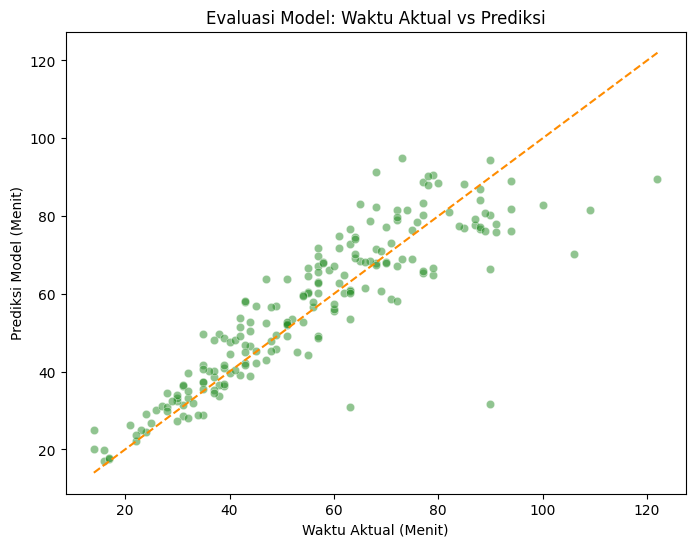

In [ ]:
#scatter plot
plt.figure(figsize=(8, 6))

# Plot Scatter: Sumbu X = Data Asli, Sumbu Y = Prediksi Model
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='forestgreen')
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='darkorange', linestyle='--')

plt.title('Evaluasi Model: Waktu Aktual vs Prediksi')
plt.xlabel('Waktu Aktual (Menit)')
plt.ylabel('Prediksi Model (Menit)')
plt.show()

/tmp/ipython-input-1841920019.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=fi_df, palette='crest')


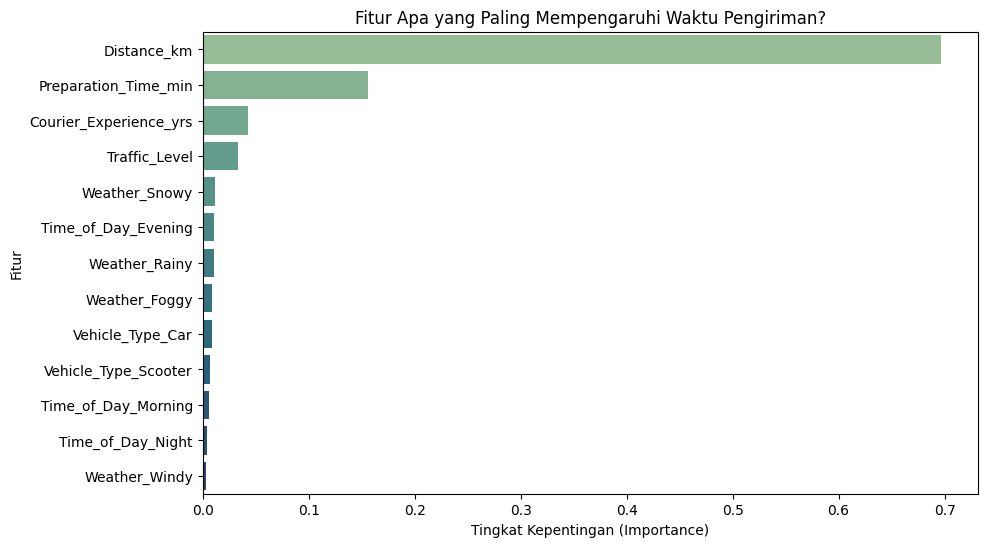

In [ ]:
#feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# DataFrame
fi_df = pd.DataFrame({'Fitur': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Fitur', data=fi_df, palette='crest')
plt.title('Fitur Apa yang Paling Mempengaruhi Waktu Pengiriman?')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.show()

### Random Forest (w/ Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest (w/tuning) ---
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]

}

# Grid Search
rf_tuned = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                        param_grid=param_grid,
                        cv=3,
                        n_jobs=-1,
                        verbose=1)

rf_tuned.fit(X_train, y_train)

# Ambil model terbaik hasil tuning
best_rf = rf_tuned.best_estimator_

# Evaluasi Model Tuning
y_pred_tuned = best_rf.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)


print("-- evaluasi random forest (w/ tuning) --")
print(f"MAE: {mae_tuned:.2f} menit")
print(f"RMSE: {rmse_tuned:.2f}")
print(f"Akurasi (R2 Score): {r2_tuned:.2f} (atau {r2_tuned*100:.1f}%)")
print("Parameter Terbaik:", rf_tuned.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
-- evaluasi random forest (w/ tuning) --
MAE: 6.74 menit
RMSE: 9.81
Akurasi (R2 Score): 0.79 (atau 78.5%)
Parameter Terbaik: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


the tuned visualize

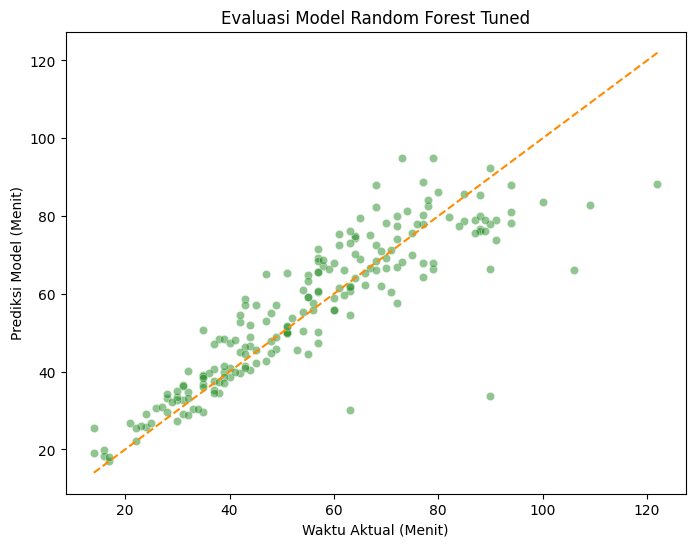

In [ ]:
#scatter plot
plt.figure(figsize=(8, 6))

# Plot Scatter: Sumbu X = Data Asli, Sumbu Y = Prediksi Model
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.5, color='forestgreen')
min_val = min(min(y_test), min(y_pred_tuned))
max_val = max(max(y_test), max(y_pred_tuned))
plt.plot([min_val, max_val], [min_val, max_val], color='darkorange', linestyle='--')

plt.title('Evaluasi Model Random Forest Tuned')
plt.xlabel('Waktu Aktual (Menit)')
plt.ylabel('Prediksi Model (Menit)')
plt.show()

/tmp/ipython-input-2359978402.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=fi_df, palette='crest')


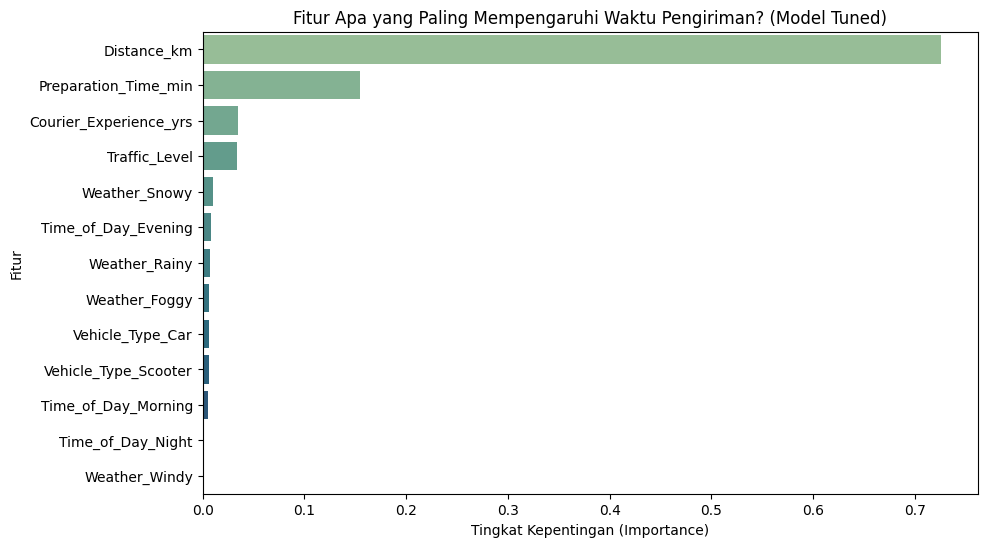

In [ ]:
#feature importance
model_terbaik = rf_tuned.best_estimator_
importances = model_terbaik.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({'Fitur': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Fitur', data=fi_df, palette='crest')
plt.title('Fitur Apa yang Paling Mempengaruhi Waktu Pengiriman? (Model Tuned)')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.show()

### comparison

In [ ]:
# result

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest (Default)",
        "Random Forest (Tuned)"
    ],
    "MAE": [
        mae_dt,
        mae,
        mae_tuned
    ],
    "RMSE": [
        np.sqrt(mse_dt),
        np.sqrt(mse),
        np.sqrt(mse_tuned)
    ],
    "R²": [
        r2_dt,
        r2,
        r2_tuned
    ]
})

results = results.round(4)

print(results)

                     Model      MAE     RMSE      R²
0            Decision Tree  11.5650  17.0630  0.3505
1  Random Forest (Default)   7.0318   9.9365  0.7797
2    Random Forest (Tuned)   6.7436   9.8090  0.7853


/tmp/ipython-input-23706664.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='viridis', ax=ax[0])
/tmp/ipython-input-23706664.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores, palette='magma', ax=ax[1])
/tmp/ipython-input-23706664.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_scores, palette='rocket', ax=ax[2])


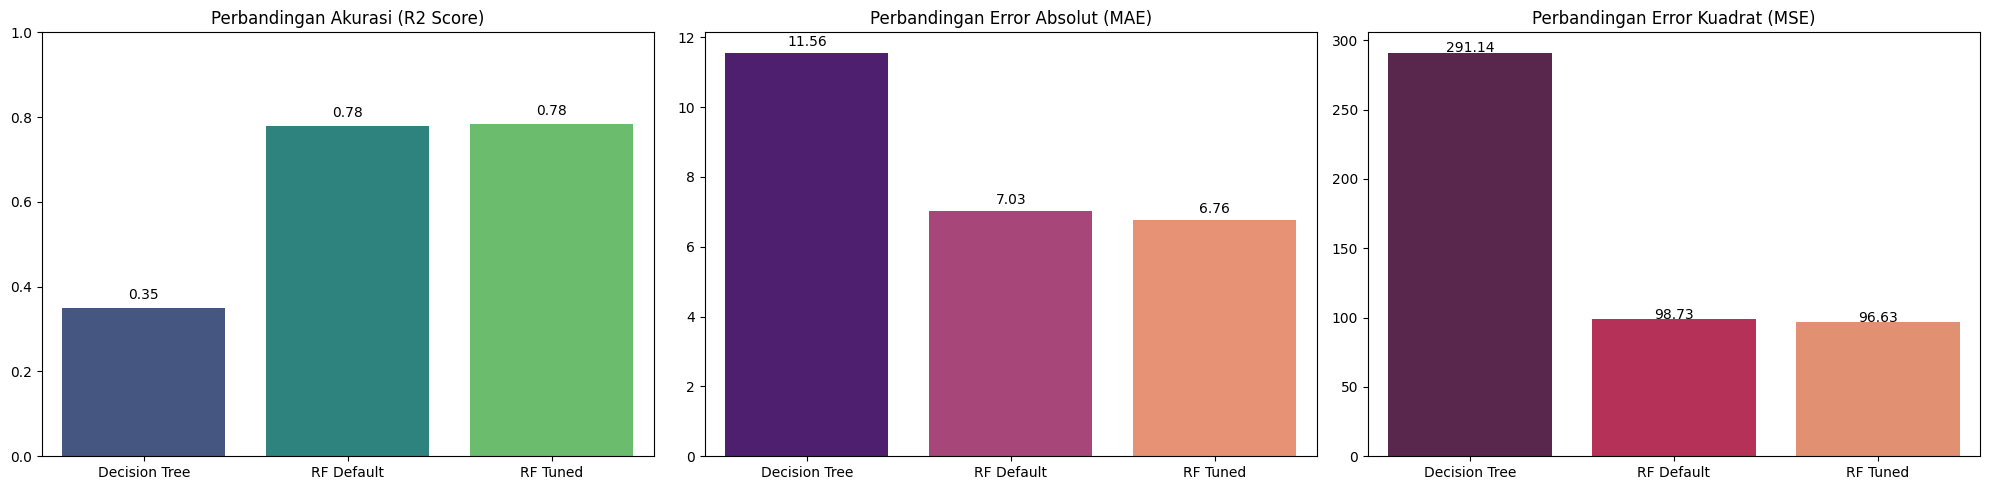

In [ ]:
# visualize
models = ['Decision Tree', 'RF Default', 'RF Tuned']
r2_scores = [r2_dt, r2, r2_tuned]
mae_scores = [mae_dt, mae, mae_tuned]
mse_scores = [mse_dt, mse, mse_tuned]

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Grafik R2 Score (Makin tinggi makin bagus)
sns.barplot(x=models, y=r2_scores, palette='viridis', ax=ax[0])
ax[0].set_title('Perbandingan Akurasi (R2 Score)')
ax[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    ax[0].text(i, v + 0.02, f"{v:.2f}", ha='center')

# Grafik MAE (Makin rendah makin bagus)
sns.barplot(x=models, y=mae_scores, palette='magma', ax=ax[1])
ax[1].set_title('Perbandingan Error Absolut (MAE)')
for i, v in enumerate(mae_scores):
    ax[1].text(i, v + 0.2, f"{v:.2f}", ha='center')

# Grafik MSE (Makin rendah makin bagus)
sns.barplot(x=models, y=mse_scores, palette='rocket', ax=ax[2])
ax[2].set_title('Perbandingan Error Kuadrat (MSE)')
for i, v in enumerate(mse_scores):
    ax[2].text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()